In [8]:
import os
import numpy as np
import pandas as pd
import seaborn as sn
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import re
import gc
from sklearn.metrics import confusion_matrix, classification_report

# Preprocessing

In [2]:
data_pd_litecoin = pd.read_csv('./data/Litecoin Historical Data - Investing.com.csv')
data_pd_monero = pd.read_csv('./data/Monero Historical Data - Investing.com.csv')

In [51]:
data_np_litecoin = data_pd_litecoin.to_numpy()[::-1,1].reshape(-1,1)
data_np_monero = data_pd_monero.to_numpy()[::-1,1].reshape(-1,1)

In [53]:
scaler_litecoin = MinMaxScaler()
data_normal_litecoin = scaler_litecoin.fit_transform(data_np_litecoin)
scaler_monero = MinMaxScaler()
data_normal_monero = scaler_monero.fit_transform(data_np_monero)

In [336]:
n = 30
data_X_litecoin = np.zeros((data_normal_litecoin.size-n,n),dtype=data_normal_litecoin.dtype)
data_y_litecoin = np.zeros((data_normal_litecoin.size-n,1),dtype=data_normal_litecoin.dtype)
for i in range(len(data_X_litecoin)):
    data_X_litecoin[i] = data_normal_litecoin[i:n+i].reshape(-1)
    data_y_litecoin[i] = data_normal_litecoin[n+i]

data_X_monero = np.zeros((data_normal_monero.size-n,n),dtype=data_normal_monero.dtype)
data_y_monero = np.zeros((data_normal_monero.size-n,1),dtype=data_normal_monero.dtype)
for i in range(len(data_X_monero)):
    data_X_monero[i] = data_normal_monero[i:n+i].reshape(-1)
    data_y_monero[i] = data_normal_monero[n+i]

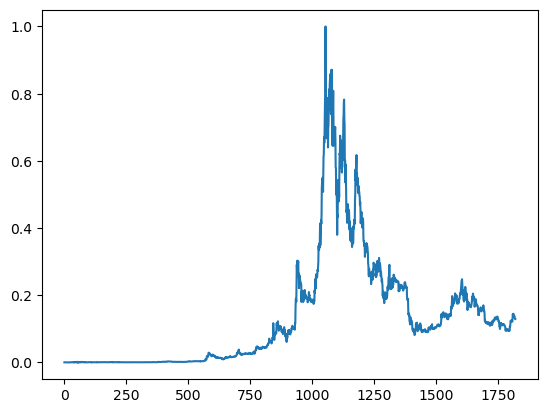

In [340]:
plt.plot(data_X_monero[:,1])

In [341]:
device = 'cpu'
X_tensor_litecoin = torch.tensor(data_X_litecoin,dtype=torch.float64,device=device).unsqueeze(-1)
y_tensor_litecoin = torch.tensor(data_y_litecoin,dtype=torch.float64,device=device)
X_tensor_monero = torch.tensor(data_X_monero,dtype=torch.float64,device=device).unsqueeze(-1)
y_tensor_monero = torch.tensor(data_y_monero,dtype=torch.float64,device=device)

In [342]:
test_ratio = 0.25
train_num = int(X_tensor_litecoin.shape[0]*(1-test_ratio))
X_train_litecoin = X_tensor_litecoin[:train_num]
X_test_litecoin = X_tensor_litecoin[train_num:]
y_train_litecoin = y_tensor_litecoin[:train_num]
y_test_litecoin = y_tensor_litecoin[train_num:]

train_num = int(X_tensor_monero.shape[0]*(1-test_ratio))
X_train_monero = X_tensor_monero[:train_num]
X_test_monero = X_tensor_monero[train_num:]
y_train_monero = y_tensor_monero[:train_num]
y_test_monero = y_tensor_monero[train_num:]

# Training

## LSTM

In [218]:
class LSTMNetwork(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super().__init__()
        self.hidden_size = hidden_size
        self.input_size = input_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(self.input_size, self.hidden_size
                            , self.num_layers, batch_first=True,dtype=torch.float64)
        self.classifier = nn.Sequential( nn.Linear(self.hidden_size, 1,dtype=torch.float64))
                                       # ,nn.Linear(128, 64)
                                        # ,nn.Linear(64, 6))
        self.relu = nn.ReLU()

    def forward(self, x):
        x, _ = self.lstm(x)        
        x = self.classifier(x[:,-1,:])
        x = self.relu(x)
        return x

### Litecoin

In [212]:
hidden_size = 50
input_size = 1
num_layers = 1
lr = 0.001
torch.manual_seed(40)
# Initialize the model, the optimizer and criterion
model_lstm_litecoin = LSTMNetwork(input_size, hidden_size, num_layers)
model_lstm_litecoin = model_lstm_litecoin.to(device)
optimizer = optim.Adam(model_lstm_litecoin.parameters(), lr=lr)
criterion = nn.MSELoss()
mae_cri = nn.L1Loss()

train_loss = np.zeros((0))
test_loss = np.zeros((0))
train_mae = np.zeros((0))
test_mae = np.zeros((0))
total_epoch_counter = 0
total_epoch = 0

In [213]:
num_epochs = 100
total_epoch += num_epochs
train_loss = np.concatenate((train_loss, np.zeros((num_epochs))), )
test_loss = np.concatenate((test_loss, np.zeros((num_epochs))), )
train_mae = np.concatenate((train_mae, np.zeros((num_epochs))), )
test_mae = np.concatenate((test_mae, np.zeros((num_epochs))), )

for epoch in range(num_epochs):
    model_lstm_litecoin.train()
    optimizer.zero_grad()
    outputs = model_lstm_litecoin(X_train_litecoin)
    loss = criterion(outputs, y_train_litecoin)
    loss.backward()
    optimizer.step()        
    with torch.inference_mode():
        test_outputs = model_lstm_litecoin(X_test_litecoin)
        t_loss = criterion(test_outputs, y_test_litecoin)
        mae_tr = mae_cri(outputs, y_train_litecoin)
        mae_ts = mae_cri(test_outputs, y_test_litecoin)

    train_loss[total_epoch_counter] = loss.detach().cpu().numpy()
    test_loss[total_epoch_counter] = t_loss.detach().cpu().numpy()
    train_mae[total_epoch_counter] = mae_tr.detach().cpu().numpy()
    test_mae[total_epoch_counter] = mae_ts.detach().cpu().numpy()

    if (epoch+1) % 10 == 0:
        print('Epoch [{}/{}], Train loss: {:.4f}, lr: {:.7f}, Train loss: {:.4f}'
               .format(total_epoch_counter+1, total_epoch, train_loss[total_epoch_counter], lr, test_loss[total_epoch_counter]))
    total_epoch_counter += 1

Epoch [10/100], Train loss: 0.0323, lr: 0.0010000, Train loss: 0.0050
Epoch [20/100], Train loss: 0.0272, lr: 0.0010000, Train loss: 0.0042
Epoch [30/100], Train loss: 0.0192, lr: 0.0010000, Train loss: 0.0031
Epoch [40/100], Train loss: 0.0047, lr: 0.0010000, Train loss: 0.0019
Epoch [50/100], Train loss: 0.0037, lr: 0.0010000, Train loss: 0.0006
Epoch [60/100], Train loss: 0.0027, lr: 0.0010000, Train loss: 0.0005
Epoch [70/100], Train loss: 0.0023, lr: 0.0010000, Train loss: 0.0005
Epoch [80/100], Train loss: 0.0022, lr: 0.0010000, Train loss: 0.0005
Epoch [90/100], Train loss: 0.0021, lr: 0.0010000, Train loss: 0.0005
Epoch [100/100], Train loss: 0.0020, lr: 0.0010000, Train loss: 0.0004


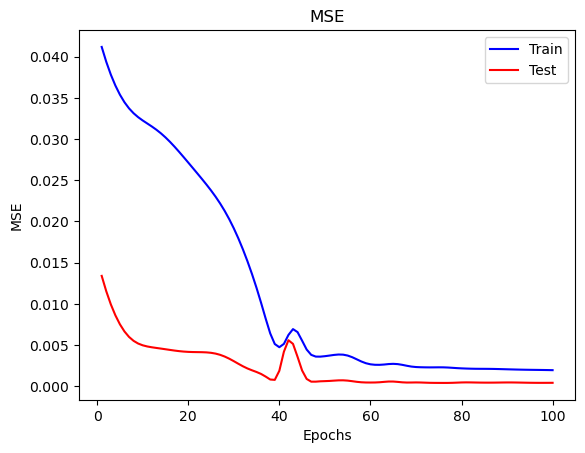

In [214]:
x = np.arange(1,len(train_loss)+1)
plt.plot(x, train_loss, 'b', label='Train')
plt.plot(x, test_loss, 'r', label='Test')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.title('MSE')
plt.legend()
plt.show()

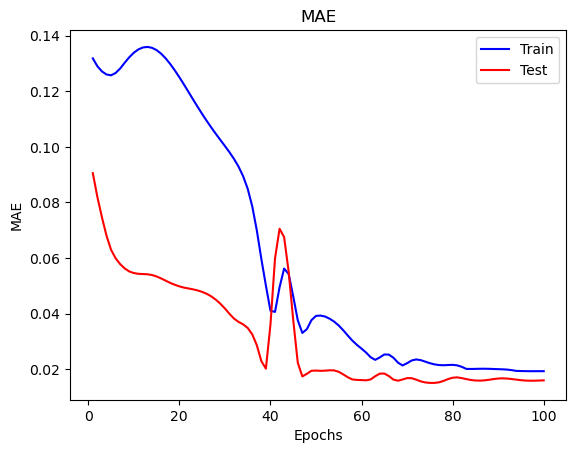

In [215]:
x = np.arange(1,len(train_mae)+1)
plt.plot(x, train_mae, 'b', label='Train')
plt.plot(x, test_mae, 'r', label='Test')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.title('MAE')
plt.legend()
plt.show()

### monero

In [343]:
hidden_size = 50
input_size = 1
num_layers = 1
lr = 0.001
torch.manual_seed(40)
# Initialize the model, the optimizer and criterion
model_lstm_monero = LSTMNetwork(input_size, hidden_size, num_layers)
model_lstm_monero = model_lstm_monero.to(device)
optimizer = optim.Adam(model_lstm_monero.parameters(), lr=lr)
criterion = nn.MSELoss()
mae_cri = nn.L1Loss()

train_loss = np.zeros((0))
test_loss = np.zeros((0))
train_mae = np.zeros((0))
test_mae = np.zeros((0))
total_epoch_counter = 0
total_epoch = 0

In [344]:
num_epochs = 100
total_epoch += num_epochs
train_loss = np.concatenate((train_loss, np.zeros((num_epochs))), )
test_loss = np.concatenate((test_loss, np.zeros((num_epochs))), )
train_mae = np.concatenate((train_mae, np.zeros((num_epochs))), )
test_mae = np.concatenate((test_mae, np.zeros((num_epochs))), )

for epoch in range(num_epochs):
    model_lstm_monero.train()
    optimizer.zero_grad()
    outputs = model_lstm_monero(X_train_monero)
    loss = criterion(outputs, y_train_monero)
    loss.backward()
    optimizer.step()        
    with torch.inference_mode():
        test_outputs = model_lstm_monero(X_test_monero)
        t_loss = criterion(test_outputs, y_test_monero)
        mae_tr = mae_cri(outputs, y_train_monero)
        mae_ts = mae_cri(test_outputs, y_test_monero)

    train_loss[total_epoch_counter] = loss.detach().cpu().numpy()
    test_loss[total_epoch_counter] = t_loss.detach().cpu().numpy()
    train_mae[total_epoch_counter] = mae_tr.detach().cpu().numpy()
    test_mae[total_epoch_counter] = mae_ts.detach().cpu().numpy()

    if (epoch+1) % 10 == 0:
        print('Epoch [{}/{}], Train loss: {:.12f}, lr: {:.7f}, Train loss: {:.12f}'
               .format(total_epoch_counter+1, total_epoch, train_loss[total_epoch_counter], lr, test_loss[total_epoch_counter]))
    total_epoch_counter += 1

Epoch [10/100], Train loss: 0.035026979204, lr: 0.0010000, Train loss: 0.001212835881
Epoch [20/100], Train loss: 0.027598357715, lr: 0.0010000, Train loss: 0.000948708347
Epoch [30/100], Train loss: 0.013178398743, lr: 0.0010000, Train loss: 0.000526337190
Epoch [40/100], Train loss: 0.004785852304, lr: 0.0010000, Train loss: 0.005849152389
Epoch [50/100], Train loss: 0.002329638142, lr: 0.0010000, Train loss: 0.000371459083
Epoch [60/100], Train loss: 0.001494633773, lr: 0.0010000, Train loss: 0.000457710951
Epoch [70/100], Train loss: 0.001269719059, lr: 0.0010000, Train loss: 0.000279154458
Epoch [80/100], Train loss: 0.001233638523, lr: 0.0010000, Train loss: 0.000256618354
Epoch [90/100], Train loss: 0.001190856476, lr: 0.0010000, Train loss: 0.000207251884
Epoch [100/100], Train loss: 0.001145622181, lr: 0.0010000, Train loss: 0.000187478746


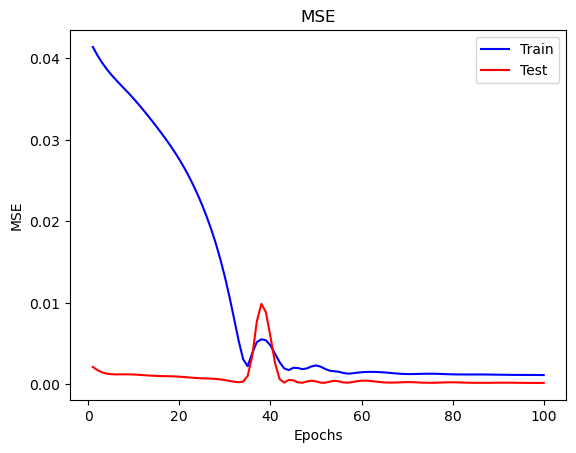

In [345]:
x = np.arange(1,len(train_loss)+1)
plt.plot(x, train_loss, 'b', label='Train')
plt.plot(x, test_loss, 'r', label='Test')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.title('MSE')
plt.legend()
plt.show()

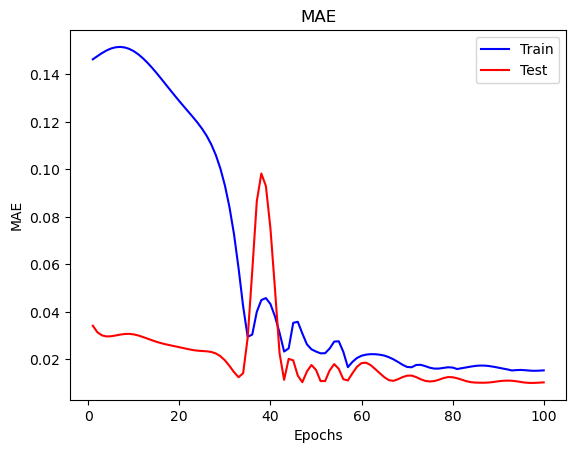

In [346]:
x = np.arange(1,len(train_mae)+1)
plt.plot(x, train_mae, 'b', label='Train')
plt.plot(x, test_mae, 'r', label='Test')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.title('MAE')
plt.legend()
plt.show()

## Propesed Model

In [468]:
class ProposedNetwork(nn.Module):
    def __init__(self, input_size, num_layers):
        super().__init__()

        self.input_size = input_size
        self.num_layers = num_layers
        
        self.lstm1 = nn.LSTM(self.input_size, 30, self.num_layers,
                             batch_first=True,dtype=torch.float64)
        
        self.dropout = nn.Dropout(p=0.25)
        
        self.lstm2 = nn.LSTM(30, 50, self.num_layers,
                    batch_first=True,dtype=torch.float64)
        
        self.fc1 = nn.Sequential(nn.Linear(50,50,dtype=torch.float64),
                    nn.ReLU(),
                    )
        
        self.gru = nn.GRU(self.input_size, 30, self.num_layers,
                              batch_first=True,dtype=torch.float64)
            
        self.fc2 = nn.Sequential(nn.Linear(30,30,dtype=torch.float64),
            nn.ReLU(),
        )
        
        self.classifier = nn.Sequential(nn.Linear(80, 32, dtype=torch.float64),
                                        nn.ReLU(),
                                       # nn.Linear(128, 64),
                                        nn.Linear(32, 1, dtype=torch.float64),
                                       )

    def forward(self, x):
        lstm1_out, _ = self.lstm1(x)
        lstm_dro_out = self.dropout(lstm1_out)
        lstm2_out, _ = self.lstm2(lstm_dro_out)
        lstm_net_out = self.fc1(lstm2_out[:,-1,:])
        
        gru_out, _ = self.gru(x)
        gru_dro_out = self.dropout(gru_out[:,-1,:])
        gru_net_out = self.fc2(gru_dro_out)

        classif_in = torch.concat((lstm_net_out, gru_net_out), dim=1)
        classif_out = self.classifier(classif_in)
        return classif_out

### Litecoin

In [469]:
input_size = 1
num_layers = 1
lr = 0.005
torch.manual_seed(40)
# Initialize the model, the optimizer and criterion
model_proposed_litecoin = ProposedNetwork(input_size, num_layers)
model_proposed_litecoin = model_proposed_litecoin.to(device)
optimizer = optim.Adam(model_proposed_litecoin.parameters(), lr=lr)
criterion = nn.MSELoss()
mae_cri = nn.L1Loss()

train_loss = np.zeros((0))
test_loss = np.zeros((0))
train_mae = np.zeros((0))
test_mae = np.zeros((0))
total_epoch_counter = 0
total_epoch = 0

In [470]:
num_epochs = 200
total_epoch += num_epochs
train_loss = np.concatenate((train_loss, np.zeros((num_epochs))), )
test_loss = np.concatenate((test_loss, np.zeros((num_epochs))), )
train_mae = np.concatenate((train_mae, np.zeros((num_epochs))), )
test_mae = np.concatenate((test_mae, np.zeros((num_epochs))), )

for epoch in range(num_epochs):
    model_proposed_litecoin.train()
    optimizer.zero_grad()
    outputs = model_proposed_litecoin(X_train_litecoin)
    loss = criterion(outputs, y_train_litecoin)
    loss.backward()
    optimizer.step()        
    with torch.inference_mode():
        test_outputs = model_proposed_litecoin(X_test_litecoin)
        t_loss = criterion(test_outputs, y_test_litecoin)
        mae_tr = mae_cri(outputs, y_train_litecoin)
        mae_ts = mae_cri(test_outputs, y_test_litecoin)

    train_loss[total_epoch_counter] = loss.detach().cpu().numpy()
    test_loss[total_epoch_counter] = t_loss.detach().cpu().numpy()
    train_mae[total_epoch_counter] = mae_tr.detach().cpu().numpy()
    test_mae[total_epoch_counter] = mae_ts.detach().cpu().numpy()

    if (epoch+1) % 10 == 0:
        print('Epoch [{}/{}], Train loss: {:.4f}, lr: {:.7f}, Train loss: {:.4f}'
               .format(total_epoch_counter+1, total_epoch, train_loss[total_epoch_counter], lr, test_loss[total_epoch_counter]))
    total_epoch_counter += 1

Epoch [10/200], Train loss: 0.0149, lr: 0.0050000, Train loss: 0.0028
Epoch [20/200], Train loss: 0.0032, lr: 0.0050000, Train loss: 0.0012
Epoch [30/200], Train loss: 0.0022, lr: 0.0050000, Train loss: 0.0008
Epoch [40/200], Train loss: 0.0014, lr: 0.0050000, Train loss: 0.0006
Epoch [50/200], Train loss: 0.0014, lr: 0.0050000, Train loss: 0.0004
Epoch [60/200], Train loss: 0.0012, lr: 0.0050000, Train loss: 0.0004
Epoch [70/200], Train loss: 0.0011, lr: 0.0050000, Train loss: 0.0004
Epoch [80/200], Train loss: 0.0010, lr: 0.0050000, Train loss: 0.0005
Epoch [90/200], Train loss: 0.0009, lr: 0.0050000, Train loss: 0.0004
Epoch [100/200], Train loss: 0.0008, lr: 0.0050000, Train loss: 0.0003
Epoch [110/200], Train loss: 0.0007, lr: 0.0050000, Train loss: 0.0003
Epoch [120/200], Train loss: 0.0007, lr: 0.0050000, Train loss: 0.0003
Epoch [130/200], Train loss: 0.0007, lr: 0.0050000, Train loss: 0.0003
Epoch [140/200], Train loss: 0.0007, lr: 0.0050000, Train loss: 0.0003
Epoch [150/200]

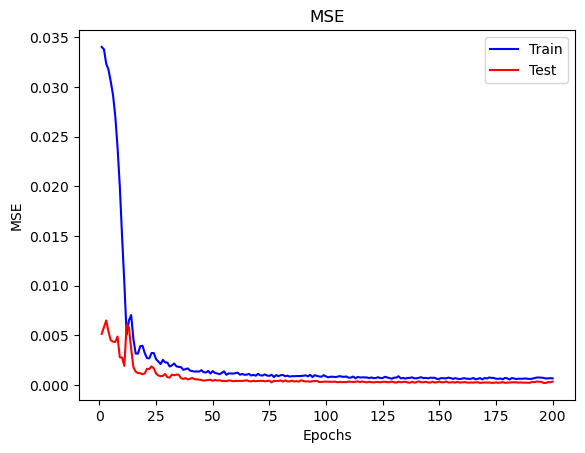

In [471]:
x = np.arange(1,len(train_loss)+1)
plt.plot(x, train_loss, 'b', label='Train')
plt.plot(x, test_loss, 'r', label='Test')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.title('MSE')
plt.legend()
plt.show()

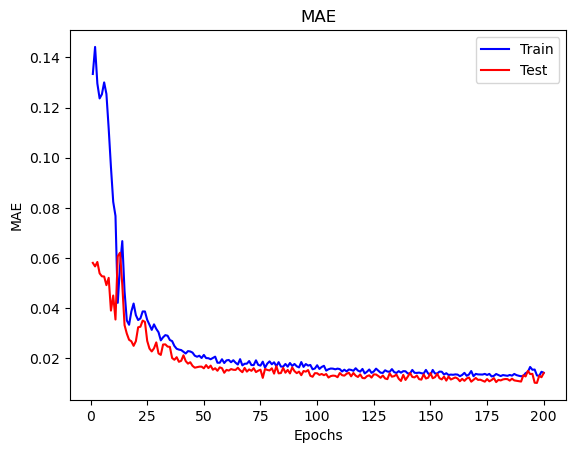

In [472]:
x = np.arange(1,len(train_mae)+1)
plt.plot(x, train_mae, 'b', label='Train')
plt.plot(x, test_mae, 'r', label='Test')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.title('MAE')
plt.legend()
plt.show()

### monero

In [477]:
input_size = 1
num_layers = 1
lr = 0.005
torch.manual_seed(40)
# Initialize the model, the optimizer and criterion
model_proposed_monero = ProposedNetwork(input_size, num_layers)
model_proposed_monero = model_proposed_monero.to(device)
optimizer = optim.Adam(model_proposed_monero.parameters(), lr=lr)
criterion = nn.MSELoss()
mae_cri = nn.L1Loss()

train_loss = np.zeros((0))
test_loss = np.zeros((0))
train_mae = np.zeros((0))
test_mae = np.zeros((0))
total_epoch_counter = 0
total_epoch = 0

In [478]:
num_epochs = 200
total_epoch += num_epochs
train_loss = np.concatenate((train_loss, np.zeros((num_epochs))), )
test_loss = np.concatenate((test_loss, np.zeros((num_epochs))), )
train_mae = np.concatenate((train_mae, np.zeros((num_epochs))), )
test_mae = np.concatenate((test_mae, np.zeros((num_epochs))), )

for epoch in range(num_epochs):
    model_proposed_monero.train()
    optimizer.zero_grad()
    outputs = model_proposed_monero(X_train_monero)
    loss = criterion(outputs, y_train_monero)
    loss.backward()
    optimizer.step()        
    with torch.inference_mode():
        test_outputs = model_proposed_monero(X_test_monero)
        t_loss = criterion(test_outputs, y_test_monero)
        mae_tr = mae_cri(outputs, y_train_monero)
        mae_ts = mae_cri(test_outputs, y_test_monero)

    train_loss[total_epoch_counter] = loss.detach().cpu().numpy()
    test_loss[total_epoch_counter] = t_loss.detach().cpu().numpy()
    train_mae[total_epoch_counter] = mae_tr.detach().cpu().numpy()
    test_mae[total_epoch_counter] = mae_ts.detach().cpu().numpy()

    if (epoch+1) % 10 == 0:
        print('Epoch [{}/{}], Train loss: {:.12f}, lr: {:.7f}, Train loss: {:.12f}'
               .format(total_epoch_counter+1, total_epoch, train_loss[total_epoch_counter], lr, test_loss[total_epoch_counter]))
    total_epoch_counter += 1

Epoch [10/200], Train loss: 0.017343251589, lr: 0.0050000, Train loss: 0.001163618446
Epoch [20/200], Train loss: 0.006345027435, lr: 0.0050000, Train loss: 0.003030288319
Epoch [30/200], Train loss: 0.002529468605, lr: 0.0050000, Train loss: 0.003351013086
Epoch [40/200], Train loss: 0.001842269462, lr: 0.0050000, Train loss: 0.001191918097
Epoch [50/200], Train loss: 0.001586709364, lr: 0.0050000, Train loss: 0.001527893371
Epoch [60/200], Train loss: 0.001213046989, lr: 0.0050000, Train loss: 0.001505222153
Epoch [70/200], Train loss: 0.001149783796, lr: 0.0050000, Train loss: 0.000647981014
Epoch [80/200], Train loss: 0.000938835039, lr: 0.0050000, Train loss: 0.000602553341
Epoch [90/200], Train loss: 0.000816359366, lr: 0.0050000, Train loss: 0.000599574827
Epoch [100/200], Train loss: 0.000878611991, lr: 0.0050000, Train loss: 0.000490955065
Epoch [110/200], Train loss: 0.000929541013, lr: 0.0050000, Train loss: 0.000477933962
Epoch [120/200], Train loss: 0.000806175150, lr: 0.0

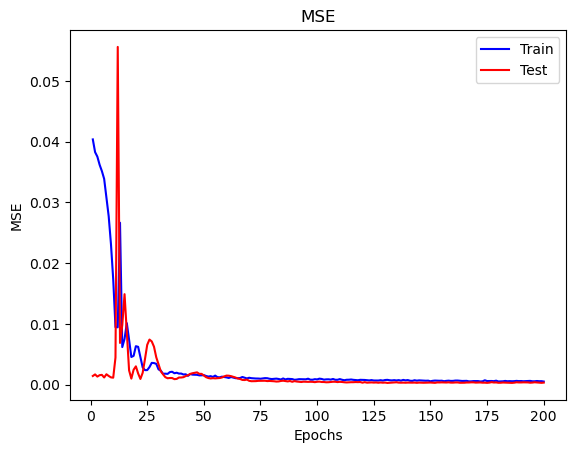

In [479]:
x = np.arange(1,len(train_loss)+1)
plt.plot(x, train_loss, 'b', label='Train')
plt.plot(x, test_loss, 'r', label='Test')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.title('MSE')
plt.legend()
plt.show()

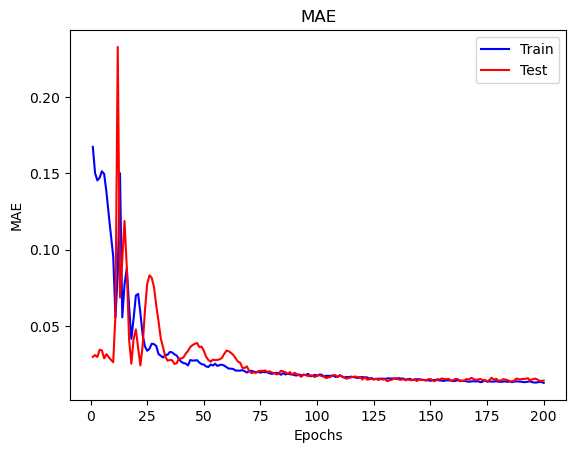

In [480]:
x = np.arange(1,len(train_mae)+1)
plt.plot(x, train_mae, 'b', label='Train')
plt.plot(x, test_mae, 'r', label='Test')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.title('MAE')
plt.legend()
plt.show()

# Evaluation

## 1 day window

In [515]:
def evaluator_1day(model,X,y,scaler):
    with torch.inference_mode():
        model.eval()
        pred = model(X)
    y = y.cpu().numpy()
    pred = pred.cpu().numpy()
    y = scaler.inverse_transform(y)
    pred = scaler.inverse_transform(pred)
    
    mse = np.sum(np.power((y-pred), 2)) / y.shape[0]
    rmse = np.sqrt(mse)
    mae = np.sum(np.abs(y-pred)) / y.shape[0]
    mape = np.sum(np.abs((y-pred) / y)) / y.shape[0]
    print(f'MSE = {mse:.4f}, RMSE = {rmse:.4f}, MAE = {mae:.4f}, MAPE = {mape:.4f}')

In [516]:
evaluator_1day(model_lstm_litecoin, X_test_litecoin, y_test_litecoin, scaler_litecoin)

MSE = 53.9123, RMSE = 7.3425, MAE = 5.6762, MAPE = 0.0793


In [517]:
evaluator_1day(model_lstm_monero, X_test_monero, y_test_monero, scaler_monero)

MSE = 42.2823, RMSE = 6.5025, MAE = 4.8913, MAPE = 0.0769


In [521]:
evaluator_1day(model_proposed_litecoin, X_test_litecoin, y_test_litecoin, scaler_litecoin)

MSE = 28.5468, RMSE = 5.3429, MAE = 4.2808, MAPE = 0.0614


In [522]:
evaluator_1day(model_proposed_monero, X_test_monero, y_test_monero, scaler_monero)

MSE = 12.6868, RMSE = 3.5619, MAE = 2.5661, MAPE = 0.0396


## 3 days window

In [523]:
def evaluator_3day(model,X,y,scaler):
    
    y_fin_pred = torch.zeros((0,1), dtype=torch.float64)
    y_fin_true = torch.zeros((0,1), dtype=torch.float64)
    for i in range(y.shape[0]-2):
        new_X = X[i:i+1]
        for j in range(3):
            with torch.inference_mode():
                model.eval()
                pred = model(new_X)
            # print(y_fin_pred.shape, y_test_litecoin[i+j].unsqueeze(0).shape)
            y_fin_pred = torch.concat((y_fin_pred,pred))
            y_fin_true = torch.concat((y_fin_true,y[i+j].unsqueeze(0)))
            new_X = torch.concat((new_X[0,1:],pred)).unsqueeze(0)
        
    y = y_fin_true.cpu().numpy()
    pred = y_fin_pred.cpu().numpy()
    y = scaler.inverse_transform(y)
    pred = scaler.inverse_transform(pred)
    
    mse = np.sum(np.power((y-pred), 2)) / y.shape[0]
    rmse = np.sqrt(mse)
    mae = np.sum(np.abs(y-pred)) / y.shape[0]
    mape = np.sum(np.abs((y-pred) / y)) / y.shape[0]
    print(f'MSE = {mse:.4f}, RMSE = {rmse:.4f}, MAE = {mae:.4f}, MAPE = {mape:.4f}')

In [524]:
evaluator_3day(model_lstm_litecoin, X_test_litecoin, y_test_litecoin, scaler_litecoin)

MSE = 65.6566, RMSE = 8.1029, MAE = 6.2809, MAPE = 0.0879


In [525]:
evaluator_3day(model_lstm_monero, X_test_monero, y_test_monero, scaler_monero)

MSE = 49.2420, RMSE = 7.0173, MAE = 5.3163, MAPE = 0.0835


In [526]:
evaluator_3day(model_proposed_litecoin, X_test_litecoin, y_test_litecoin, scaler_litecoin)

MSE = 71.0468, RMSE = 8.4289, MAE = 6.4606, MAPE = 0.0910


In [527]:
evaluator_3day(model_proposed_monero, X_test_monero, y_test_monero, scaler_monero)

MSE = 23.4632, RMSE = 4.8439, MAE = 3.4697, MAPE = 0.0531


## 7 days window

In [528]:
def evaluator_7day(model,X,y,scaler):
    y_fin_pred = torch.zeros((0,1), dtype=torch.float64)
    y_fin_true = torch.zeros((0,1), dtype=torch.float64)
    for i in range(y.shape[0]-6):
        new_X = X[i:i+1]
        for j in range(7):
            with torch.inference_mode():
                pred = model(new_X)
            # print(y_fin_pred.shape, y_test_litecoin[i+j].unsqueeze(0).shape)
            y_fin_pred = torch.concat((y_fin_pred,pred))
            y_fin_true = torch.concat((y_fin_true,y[i+j].unsqueeze(0)))
            new_X = torch.concat((new_X[0,1:],pred)).unsqueeze(0)
        
    y = y_fin_true.cpu().numpy()
    pred = y_fin_pred.cpu().numpy()
    y = scaler.inverse_transform(y)
    pred = scaler.inverse_transform(pred)
    
    mse = np.sum(np.power((y-pred), 2)) / y.shape[0]
    rmse = np.sqrt(mse)
    mae = np.sum(np.abs(y-pred)) / y.shape[0]
    mape = np.sum(np.abs((y-pred) / y)) / y.shape[0]
    print(f'MSE = {mse:.4f}, RMSE = {rmse:.4f}, MAE = {mae:.4f}, MAPE = {mape:.4f}')

In [529]:
evaluator_7day(model_lstm_litecoin, X_test_litecoin, y_test_litecoin, scaler_litecoin)

MSE = 95.4835, RMSE = 9.7716, MAE = 7.6386, MAPE = 0.1074


In [530]:
evaluator_7day(model_lstm_monero, X_test_monero, y_test_monero, scaler_monero)

MSE = 66.7425, RMSE = 8.1696, MAE = 6.2247, MAPE = 0.0982


In [531]:
evaluator_7day(model_proposed_litecoin, X_test_litecoin, y_test_litecoin, scaler_litecoin)

MSE = 292.5338, RMSE = 17.1036, MAE = 11.6141, MAPE = 0.1568


In [532]:
evaluator_7day(model_proposed_monero, X_test_monero, y_test_monero, scaler_monero)

MSE = 52.5452, RMSE = 7.2488, MAE = 5.1328, MAPE = 0.0776
